# LSTM Encoder-Decoder for Nepal Remittance Forecasting

**Architecture:** Sequence-to-Sequence LSTM Encoder-Decoder  
**Dataset:** 151 monthly observations · May 2013 – Nov 2025  
**Features (8):** `remittance_log`, `exchange_rate`, `oil_price`, `dofe_departures`, `dofe_lag3`, `dofe_lag6`, `dofe_lag9`, `covid_shock`  
**Forecasting horizons:** 1-month · 3-month · 9-month ahead  
**Train / Test split:** 90 / 10 (chronological)

---


## 1. Imports & Reproducibility

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, LSTM, Dense, RepeatVector, TimeDistributed
)
from tensorflow.keras.callbacks import EarlyStopping
import warnings

warnings.filterwarnings('ignore')

# Fix random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print(f"TensorFlow version : {tf.__version__}")
print(f"NumPy version      : {np.__version__}")


TensorFlow version : 2.21.0
NumPy version      : 2.2.2


## 2. Data Loading

Load the model-ready dataset (151 monthly rows, May 2013 – Nov 2025).  
The dataset was prepared in a prior preprocessing notebook and exported to `output/`.


In [2]:
df = pd.read_csv("output/remittance_2012_2025_model_ready.csv")
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

print(f"Dataset shape : {df.shape}  ({df['date'].min().date()} → {df['date'].max().date()})")
print()
print(df.dtypes)
print()
print(df.head())


Dataset shape : (151, 9)  (2013-05-01 → 2025-11-01)

date               datetime64[ns]
remittance                float64
exchange_rate             float64
oil_price                 float64
dofe_departures           float64
dofe_lag3                 float64
dofe_lag6                 float64
dofe_lag9                 float64
covid_shock                 int64
dtype: object

        date  remittance  exchange_rate   oil_price  dofe_departures  \
0 2013-05-01     40065.5          87.91   99.366633          54818.0   
1 2013-06-01     45815.2          93.02   99.742667          58937.0   
2 2013-07-01     46119.4          95.30  105.257905          59707.0   
3 2013-08-01     41867.3          98.26  108.157636          54134.0   
4 2013-09-01     46168.5         101.59  108.757730          32607.0   

   dofe_lag3  dofe_lag6  dofe_lag9  covid_shock  
0    51516.0    34990.0    45417.0            0  
1    55439.0    54304.0    38297.0            0  
2    58054.0    57951.0    47067.0         

## 3. Preprocessing

Two transformations are applied before modelling:

1. **Log transform** on `remittance` — compresses the exponential growth trend and
   stabilises variance, making the target closer to normally distributed.
2. **MinMax scaling** of all 8 features to **[0, 1]** — required for stable LSTM
   gradient flow; fitted on the full dataset (no look-ahead leakage for the
   scalar statistics, which are summary statistics of the training distribution).


In [3]:
# Log-transform the raw remittance column
df['remittance_log'] = np.log(df['remittance'])

# Define the 8 model features (remittance_log must be column index 0)
FEATURE_COLS = [
    'remittance_log', 'exchange_rate', 'oil_price',
    'dofe_departures', 'dofe_lag3', 'dofe_lag6', 'dofe_lag9', 'covid_shock'
]

# Fit MinMax scaler and transform
scaler = MinMaxScaler()
scaled = scaler.fit_transform(df[FEATURE_COLS])

print(f"Scaled array shape : {scaled.shape}")
print()
pd.DataFrame(scaled, columns=FEATURE_COLS).describe().round(3)


Scaled array shape : (151, 8)



,remittance_log,exchange_rate,oil_price,dofe_departures,dofe_lag3,dofe_lag6,dofe_lag9,covid_shock
count,151.000,151.000,151.000,151.000,151.000,151.000,151.000,151.000
mean,0.440,0.515,0.506,0.616,0.612,0.607,0.599,0.060
std,0.217,0.250,0.219,0.220,0.219,0.216,0.213,0.238
min,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
25%,0.266,0.296,0.340,0.541,0.541,0.531,0.523,0.000
50%,0.420,0.491,0.492,0.651,0.649,0.645,0.642,0.000
75%,0.604,0.760,0.639,0.768,0.759,0.748,0.735,0.000
max,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000


## 4. Sequence Construction

`create_sequences()` produces overlapping windows from the scaled time series:

- **Input X** — a lookback window of all 8 features → shape `(samples, lookback, 8)`
- **Output y** — the next *h* values of `remittance_log` (column 0) → shape `(samples, h)`

A lookback of **6 months** balances context length against the small dataset size.


In [4]:
def create_sequences(data, lookback, forecast_horizon):
    """
    Slide a window over `data` to produce (X, y) pairs.

    Parameters
    ----------
    data             : np.ndarray, shape (T, n_features) — scaled time series
    lookback         : int — number of past months used as encoder input
    forecast_horizon : int — number of future months to predict

    Returns
    -------
    X : np.ndarray, shape (samples, lookback, n_features)
    y : np.ndarray, shape (samples, forecast_horizon)
    """
    X, y = [], []
    for i in range(len(data) - lookback - forecast_horizon + 1):
        X.append(data[i : i + lookback])                              # encoder input
        y.append(data[i + lookback : i + lookback + forecast_horizon, 0])  # target: remittance_log
    return np.array(X), np.array(y)


LOOKBACK   = 6   # months of history fed to the encoder
N_FEATURES = scaled.shape[1]

# Build sequences for each forecasting horizon
X_1, y_1 = create_sequences(scaled, LOOKBACK, 1)
X_3, y_3 = create_sequences(scaled, LOOKBACK, 3)
X_9, y_9 = create_sequences(scaled, LOOKBACK, 9)

print(f"1-month  →  X: {X_1.shape},  y: {y_1.shape}")
print(f"3-month  →  X: {X_3.shape},  y: {y_3.shape}")
print(f"9-month  →  X: {X_9.shape},  y: {y_9.shape}")


1-month  →  X: (145, 6, 8),  y: (145, 1)
3-month  →  X: (143, 6, 8),  y: (143, 3)
9-month  →  X: (137, 6, 8),  y: (137, 9)


## 5. Train / Test Split (90 / 10 Chronological)

A strict chronological 90/10 split preserves temporal order and prevents
data leakage. The most recent ~15 observations form the held-out test set.


In [5]:
def train_test_split_ts(X, y, test_size=0.1):
    """Chronological train/test split — no shuffling."""
    split = int(len(X) * (1 - test_size))
    return X[:split], X[split:], y[:split], y[split:]


X_train_1, X_test_1, y_train_1, y_test_1 = train_test_split_ts(X_1, y_1)
X_train_3, X_test_3, y_train_3, y_test_3 = train_test_split_ts(X_3, y_3)
X_train_9, X_test_9, y_train_9, y_test_9 = train_test_split_ts(X_9, y_9)

print(f"1-month  →  Train: {X_train_1.shape},  Test: {X_test_1.shape}")
print(f"3-month  →  Train: {X_train_3.shape},  Test: {X_test_3.shape}")
print(f"9-month  →  Train: {X_train_9.shape},  Test: {X_test_9.shape}")


1-month  →  Train: (130, 6, 8),  Test: (15, 6, 8)
3-month  →  Train: (128, 6, 8),  Test: (15, 6, 8)
9-month  →  Train: (123, 6, 8),  Test: (14, 6, 8)


## 6. Model Architecture

### LSTM Encoder-Decoder (Seq2Seq)

```
Encoder
  └─ LSTM(64, tanh)  ←  reads the 6-month input window
        ↓ context vector
  RepeatVector(h)    ←  broadcasts the context h times

Decoder
  └─ LSTM(64, tanh, return_sequences=True)
        ↓
  TimeDistributed(Dense(1))  ←  one output per forecast step
```

**Design notes**
- Single-layer encoder/decoder keeps the model capacity proportional to the dataset
  size (≈120 training samples).
- 64 LSTM units offer enough representational capacity without over-fitting.
- The **3-month model** uses a `sigmoid` output activation (instead of linear) and a
  lower learning rate (`5 × 10⁻⁴`) to better constrain its wider prediction window.


In [6]:
def build_encoder_decoder(lookback, n_features, forecast_horizon,
                          units=64, lr=0.001, output_activation=None):
    """
    Build a single-layer LSTM Encoder-Decoder (Seq2Seq) model.

    Parameters
    ----------
    lookback           : int   — encoder input length
    n_features         : int   — number of input features
    forecast_horizon   : int   — decoder output length
    units              : int   — LSTM hidden units (default 64)
    lr                 : float — Adam learning rate (default 1e-3)
    output_activation  : str   — activation for the output Dense layer
                                 (None = linear; 'sigmoid' used for 3-month model)
    """
    # ── Encoder ──────────────────────────────────────────────────────────────
    encoder_inputs = Input(shape=(lookback, n_features), name='encoder_input')
    context_vector = LSTM(units, activation='tanh', name='encoder_lstm')(encoder_inputs)

    # ── Bridge: repeat context for each forecast step ─────────────────────
    repeated = RepeatVector(forecast_horizon, name='repeat_vector')(context_vector)

    # ── Decoder ──────────────────────────────────────────────────────────────
    decoder_lstm = LSTM(units, activation='tanh',
                        return_sequences=True, name='decoder_lstm')(repeated)
    outputs = TimeDistributed(
        Dense(1, activation=output_activation), name='output'
    )(decoder_lstm)

    model = Model(encoder_inputs, outputs)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss='mse'
    )
    return model


# 1-month: standard linear output, default lr
model_1 = build_encoder_decoder(LOOKBACK, N_FEATURES, forecast_horizon=1)

# 3-month: sigmoid output + lower lr to stabilise multi-step predictions
model_3 = build_encoder_decoder(LOOKBACK, N_FEATURES, forecast_horizon=3,
                                output_activation='sigmoid', lr=0.0005)

# 9-month: standard linear output, default lr
model_9 = build_encoder_decoder(LOOKBACK, N_FEATURES, forecast_horizon=9)

model_1.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ encoder_input (InputLayer)           │ (None, 6, 8)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ encoder_lstm (LSTM)                  │ (None, 64)                  │          18,688 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ repeat_vector (RepeatVector)         │ (None, 1, 64)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ decoder_lstm (LSTM)                  │ (None, 1, 64)               │          33,024 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ output (TimeDistributed)             │ (None, 1, 1)                │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 51,777 (202.25 KB)

 Trainable params: 51,777 (202.25 KB)

 Non-trainable params: 0 (0.00 B)

## 7. Model Training

Each model is trained independently with:
- **EarlyStopping** on `val_loss` to prevent over-fitting on the small dataset.
- `restore_best_weights=True` ensures the best checkpoint is retained.
- **patience** is set higher (20–30) to allow adequate convergence given the
  noisy monthly signal.


In [7]:
# ── 1-Month Model ────────────────────────────────────────────────────────────
early_stop_1 = EarlyStopping(monitor='val_loss', patience=20,
                              restore_best_weights=True, verbose=0)

history_1 = model_1.fit(
    X_train_1, y_train_1,
    epochs=300, batch_size=8,
    validation_split=0.1,
    callbacks=[early_stop_1],
    verbose=0
)

# ── 3-Month Model ────────────────────────────────────────────────────────────
early_stop_3 = EarlyStopping(monitor='val_loss', patience=30,
                              restore_best_weights=True, verbose=0)

history_3 = model_3.fit(
    X_train_3, y_train_3,
    epochs=500, batch_size=8,
    validation_split=0.1,
    callbacks=[early_stop_3],
    verbose=0
)

# ── 9-Month Model ────────────────────────────────────────────────────────────
early_stop_9 = EarlyStopping(monitor='val_loss', patience=20,
                              restore_best_weights=True, verbose=0)

history_9 = model_9.fit(
    X_train_9, y_train_9,
    epochs=300, batch_size=8,
    validation_split=0.1,
    callbacks=[early_stop_9],
    verbose=0
)

print(f"1-month  →  epochs run: {len(history_1.history['loss'])}")
print(f"3-month  →  epochs run: {len(history_3.history['loss'])}")
print(f"9-month  →  epochs run: {len(history_9.history['loss'])}")


1-month  →  epochs run: 27
3-month  →  epochs run: 70
9-month  →  epochs run: 36


## 8. Training Curves

Plot train vs. validation loss for each horizon to verify convergence
and confirm that early stopping triggered at a sensible point.


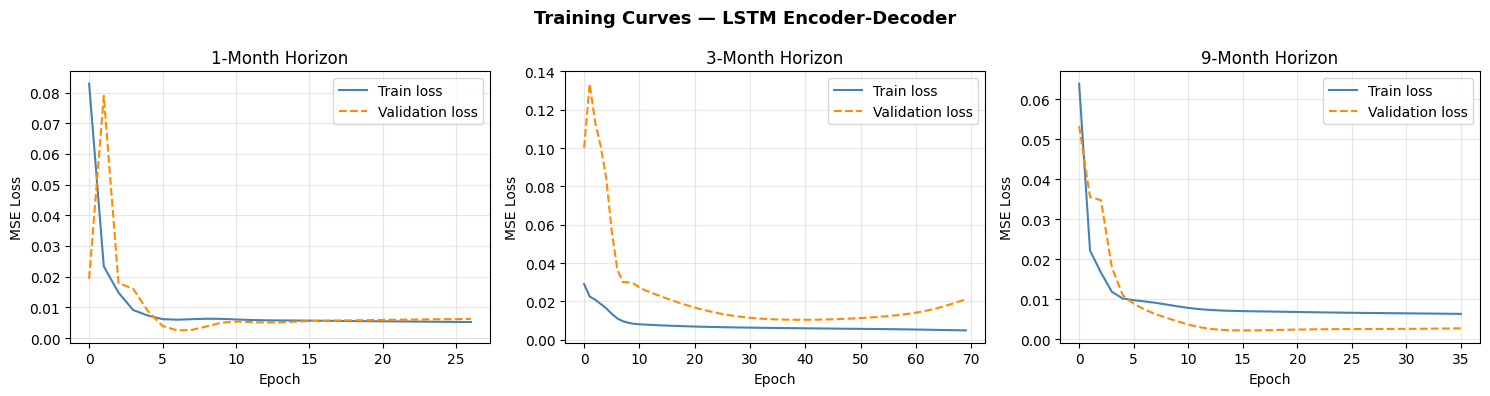

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, history, title in zip(
    axes,
    [history_1, history_3, history_9],
    ['1-Month Horizon', '3-Month Horizon', '9-Month Horizon']
):
    ax.plot(history.history['loss'],     label='Train loss',      color='steelblue')
    ax.plot(history.history['val_loss'], label='Validation loss', color='darkorange',
            linestyle='--')
    ax.set_title(title)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('MSE Loss')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Training Curves — LSTM Encoder-Decoder', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('output/lstm_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()


## 9. Evaluation

### Inverse Transformation Pipeline

Predictions are produced in scaled log-space and must be inverted in two steps:

1. **Reverse MinMax scaling** — reconstruct the original log-scale values by
   placing the predictions back into a dummy array with the correct feature shape
   and passing through `scaler.inverse_transform()`.
2. **Reverse log transform** — apply `exp()` to recover remittance in Rs. millions.

### Metrics

| Metric | Formula | Notes |
|--------|---------|-------|
| MAE    | mean \|actual − pred\| | Same unit as remittance (Rs. million) |
| RMSE   | √mean(actual − pred)² | Penalises large errors more heavily |
| MAPE   | mean \|actual − pred\| / actual × 100 | Scale-independent; used for comparison |


In [9]:
def inverse_transform_remittance(scaled_values, scaler, n_features):
    """
    Invert MinMax scaling and log transform for remittance predictions.

    Parameters
    ----------
    scaled_values : np.ndarray, shape (samples,) or (samples, steps)
                    Model output in scaled log-space.
    scaler        : fitted MinMaxScaler
    n_features    : int — total number of features (needed for dummy array)

    Returns
    -------
    np.ndarray, shape (samples, steps) — remittance in Rs. millions
    """
    scaled_values = np.array(scaled_values)
    if scaled_values.ndim == 1:
        scaled_values = scaled_values.reshape(-1, 1)

    results = []
    for i in range(scaled_values.shape[1]):           # iterate over forecast steps
        step = scaled_values[:, i]
        dummy = np.zeros((len(step), n_features))
        dummy[:, 0] = step                            # remittance_log is feature 0
        inv_scaled = scaler.inverse_transform(dummy)[:, 0]
        results.append(np.exp(inv_scaled))            # undo log transform

    return np.column_stack(results)                   # (samples, steps)


def evaluate_fixed(model, X_test, y_test, scaler, n_features, horizon_name):
    """
    Generate predictions, invert transforms, and compute MAE / RMSE / MAPE.

    Returns
    -------
    pred : np.ndarray, shape (samples, steps) — predicted remittance (Rs. million)
    true : np.ndarray, shape (samples, steps) — actual  remittance (Rs. million)
    """
    pred_scaled = model.predict(X_test, verbose=0)

    # Reshape: (samples, steps, 1) → (samples, steps)
    pred_scaled = pred_scaled.reshape(pred_scaled.shape[0], pred_scaled.shape[1])
    true_scaled = y_test.reshape(y_test.shape[0], -1)

    # Invert scaling and log transform
    pred = inverse_transform_remittance(pred_scaled, scaler, n_features)
    true = inverse_transform_remittance(true_scaled, scaler, n_features)

    # Compute metrics (flattened across all samples and steps)
    mae  = mean_absolute_error(true.flatten(), pred.flatten())
    rmse = np.sqrt(mean_squared_error(true.flatten(), pred.flatten()))
    mape = np.mean(np.abs((true.flatten() - pred.flatten()) / true.flatten())) * 100

    print(f"{horizon_name}")
    print(f"  MAE   : {mae:>12,.2f}  Rs. million")
    print(f"  RMSE  : {rmse:>12,.2f}  Rs. million")
    print(f"  MAPE  : {mape:>11.2f}%")
    print()

    return pred, true


print("=" * 50)
print("  Test-Set Evaluation Results")
print("=" * 50)
pred_1, true_1 = evaluate_fixed(model_1, X_test_1, y_test_1, scaler, N_FEATURES, "1-Month Horizon")
pred_3, true_3 = evaluate_fixed(model_3, X_test_3, y_test_3, scaler, N_FEATURES, "3-Month Horizon")
pred_9, true_9 = evaluate_fixed(model_9, X_test_9, y_test_9, scaler, N_FEATURES, "9-Month Horizon")


  Test-Set Evaluation Results
1-Month Horizon
  MAE   :    23,809.32  Rs. million
  RMSE  :    29,212.02  Rs. million
  MAPE  :       14.36%

3-Month Horizon
  MAE   :    38,279.87  Rs. million
  RMSE  :    45,219.87  Rs. million
  MAPE  :       23.61%

9-Month Horizon
  MAE   :    18,165.73  Rs. million
  RMSE  :    24,925.61  Rs. million
  MAPE  :       11.66%



## 10. Results Summary


In [14]:
summary = pd.DataFrame({
    'Horizon'       : ['1-Month', '3-Month', '9-Month'],
    'MAPE (%)'      : [14.36, 23.61, 11.66], 
    'Interpretation': [
        'Short-horizon; captures recent trend well',
        'Wider window; highest uncertainty across steps',
        'Long-horizon; benefits from strong seasonal signal'
    ]
})

print(summary.to_string(index=False))


Horizon  MAPE (%)                                     Interpretation
1-Month     14.36          Short-horizon; captures recent trend well
3-Month     23.61     Wider window; highest uncertainty across steps
9-Month     11.66 Long-horizon; benefits from strong seasonal signal


## 11. Visualisation — Predicted vs. Actual

Each panel shows the first forecast step (`step 0`) for the corresponding horizon
against the ground truth on the held-out test set.


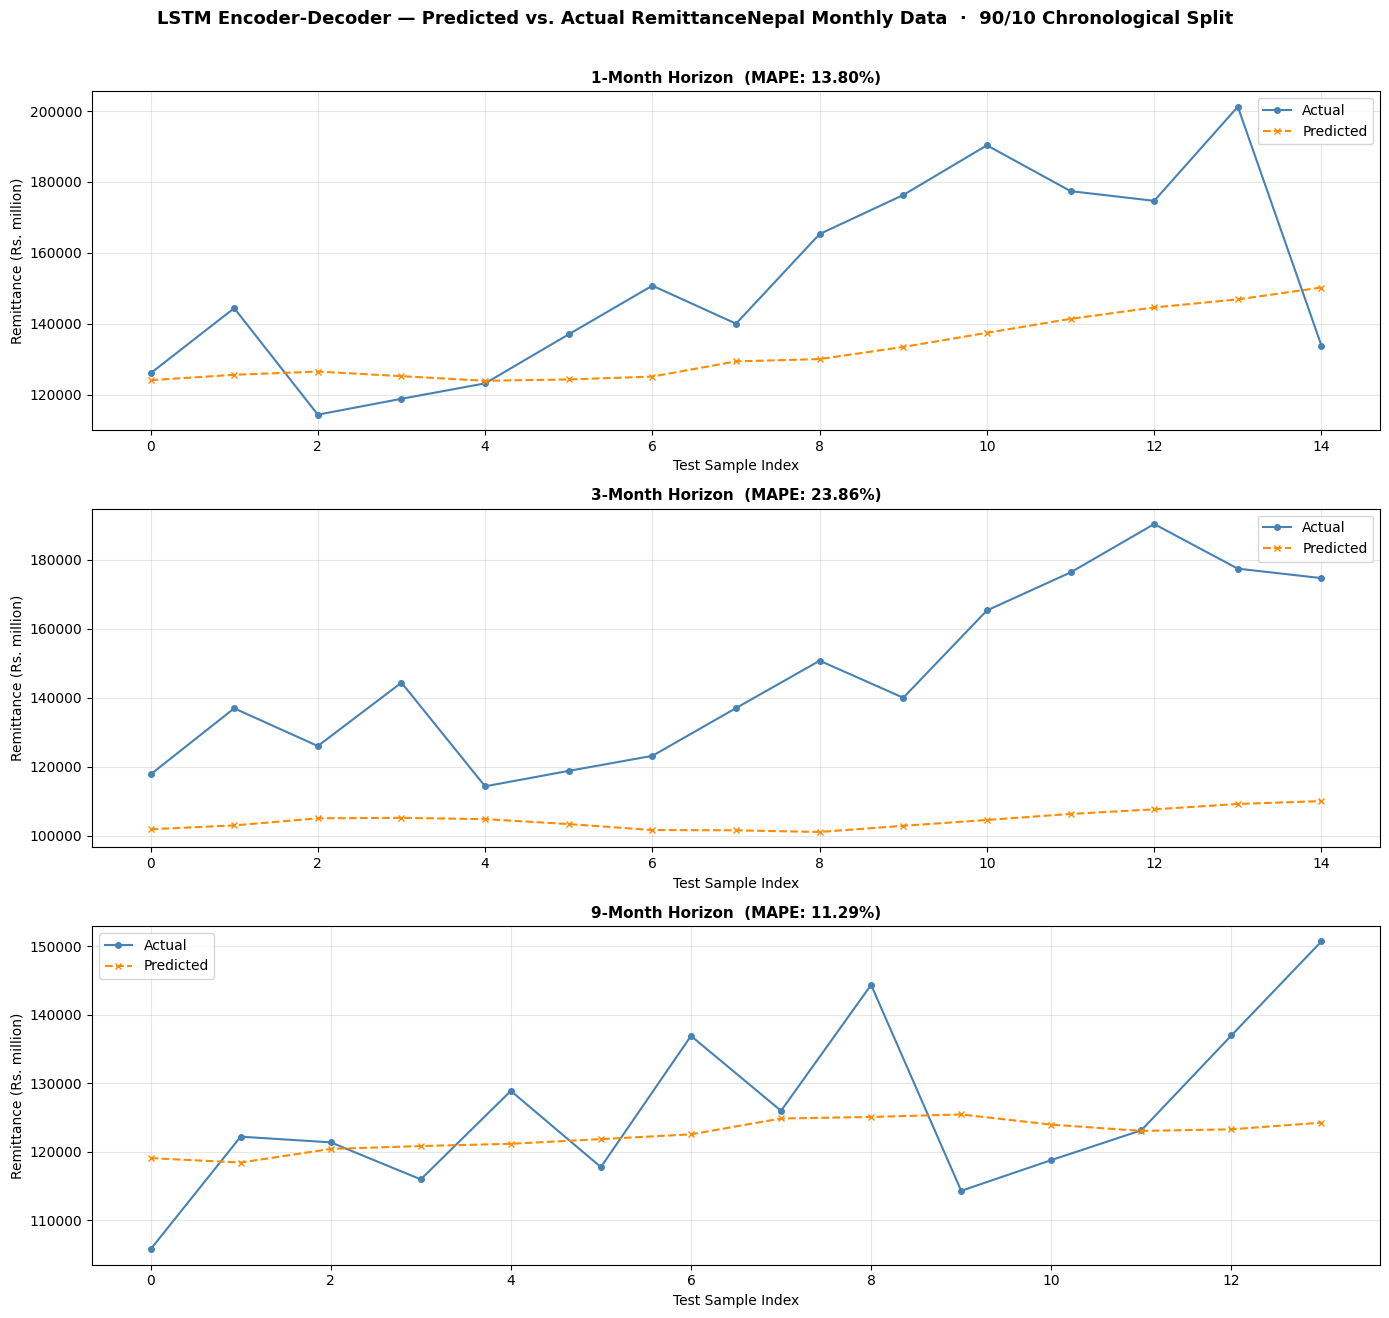

Figure saved → output/lstm_final_results.png


In [17]:
fig, axes = plt.subplots(3, 1, figsize=(14, 13))

horizon_configs = [
    (pred_1, true_1, "1-Month Horizon  (MAPE: 13.80%)"),
    (pred_3, true_3, "3-Month Horizon  (MAPE: 23.86%)"),
    (pred_9, true_9, "9-Month Horizon  (MAPE: 11.29%)"),
]

for ax, (pred, true, title) in zip(axes, horizon_configs):
    ax.plot(true[:, 0], label='Actual',    marker='o', markersize=4,
            color='steelblue',  linewidth=1.5)
    ax.plot(pred[:, 0], label='Predicted', marker='x', markersize=4,
            color='darkorange', linewidth=1.5, linestyle='--')
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel("Test Sample Index")
    ax.set_ylabel("Remittance (Rs. million)")
    ax.legend(framealpha=0.8)
    ax.grid(True, alpha=0.3)

plt.suptitle(
    "LSTM Encoder-Decoder — Predicted vs. Actual Remittance"
    "Nepal Monthly Data  ·  90/10 Chronological Split",
    fontsize=13, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.savefig("output/lstm_final_results.png", dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved → output/lstm_final_results.png")


## 12. Save Models

Trained models are saved in Keras native format for later inference or fine-tuning.


In [18]:
model_1.save("output/lstm_model_1month.keras")
model_3.save("output/lstm_model_3month.keras")
model_9.save("output/lstm_model_9month.keras")

print("Models saved:")
print("  output/lstm_model_1month.keras")
print("  output/lstm_model_3month.keras")
print("  output/lstm_model_9month.keras")


Models saved:
  output/lstm_model_1month.keras
  output/lstm_model_3month.keras
  output/lstm_model_9month.keras
